Calculando métricas...
Datos reales (Test): (72000, 120)
Datos generados: (40000, 120)


/home/javi/miniconda3/envs/crbms/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/javi/miniconda3/envs/crbms/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


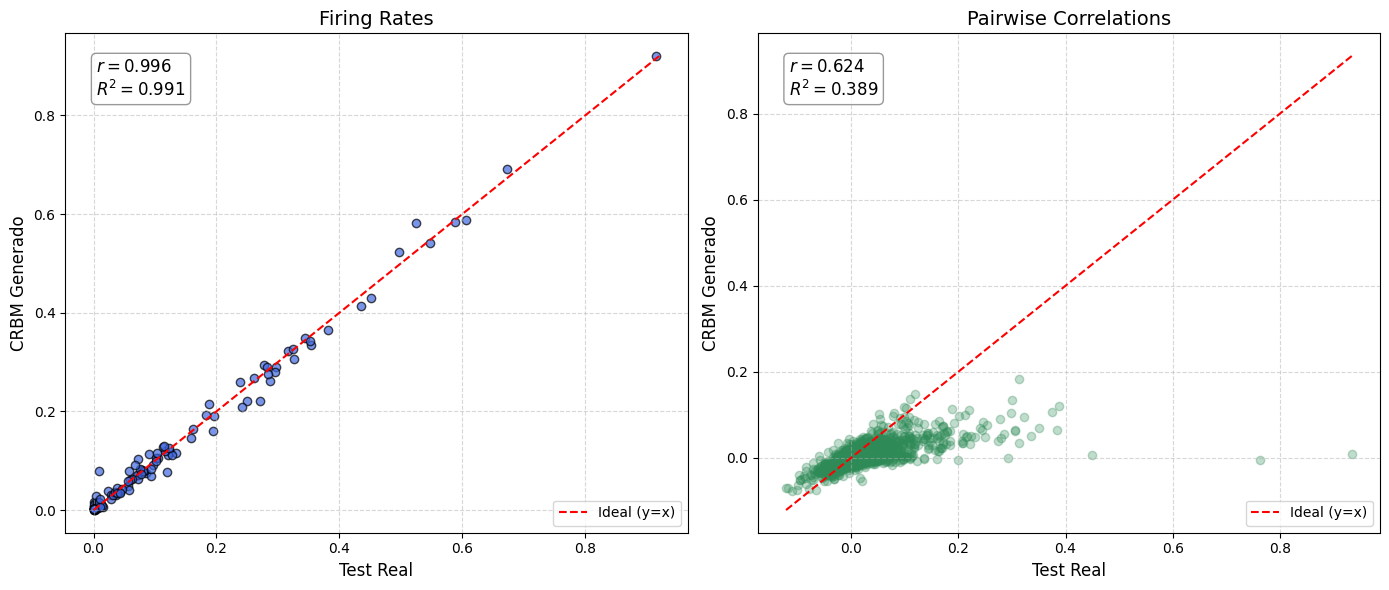

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN DE ARCHIVOS
# ==========================================
archivo_datos_reales = "data/neuronas_120.h5"
archivo_datos_generados = "sec_test_20_2.h5"
train_size = 0.6  # El porcentaje que usaste para entrenar

# ==========================================
# 2. CARGA DE DATOS
# ==========================================
# Cargar datos reales y quedarnos solo con el TEST set
with h5py.File(archivo_datos_reales, "r") as f:
    datos_reales = f["samples"][()]
    
split_idx = int(train_size * datos_reales.shape[0])
test_reales = datos_reales[split_idx:]  # Forma: (Tiempo_Test, 120)

# Cargar datos generados
with h5py.File(archivo_datos_generados, "r") as f:
    datos_gen = f["generated_sequences"][()]
    
# Si generaste múltiples secuencias, las aplanamos todas en una única dimensión temporal
# Forma original: (Num_Seqs, Tiempo_Gen, 120) -> Forma final: (Num_Seqs * Tiempo_Gen, 120)
test_gen = datos_gen.reshape(-1, datos_gen.shape[-1])

# ==========================================
# 3. CÁLCULO DE MÉTRICAS
# ==========================================
print(f"Calculando métricas...\nDatos reales (Test): {test_reales.shape}\nDatos generados: {test_gen.shape}")

# Firing Rate: Media de activación de cada neurona (eje 0 = a lo largo del tiempo)
fr_real = test_reales.mean(axis=0)
fr_gen = test_gen.mean(axis=0)

# Pairwise Correlations: Matriz de correlación de Pearson
# np.corrcoef espera que las variables sean filas, por eso transponemos (.T)
corr_real_matrix = np.corrcoef(test_reales.T)
corr_gen_matrix = np.corrcoef(test_gen.T)

# Si una neurona está "muerta" (siempre 0), corrcoef devuelve NaN. Lo rellenamos con 0.
corr_real_matrix = np.nan_to_num(corr_real_matrix)
corr_gen_matrix = np.nan_to_num(corr_gen_matrix)

# Extraemos solo el triángulo superior de la matriz para no tener pares duplicados (i,j) y (j,i)
indices_triangulo = np.triu_indices_from(corr_real_matrix, k=1)
corr_real = corr_real_matrix[indices_triangulo]
corr_gen = corr_gen_matrix[indices_triangulo]

# ==========================================
# 4. VISUALIZACIÓN (PLOTS) CON r y R^2
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Funciones auxiliares para calcular métricas ---
def calc_metrics(x, y):
    # Correlación de Pearson (r)
    r = np.corrcoef(x, y)[0, 1]
    # R cuadrado (R^2)
    r2 = r**2
    return r, r2

# Calculamos las métricas para ambos plots
r_fr, r2_fr = calc_metrics(fr_real, fr_gen)
r_corr, r2_corr = calc_metrics(corr_real, corr_gen)

# Textos para las cajas
text_fr = f"$r = {r_fr:.3f}$\n$R^2 = {r2_fr:.3f}$"
text_corr = f"$r = {r_corr:.3f}$\n$R^2 = {r2_corr:.3f}$"

# Props para las cajitas de texto
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)

# ---- PLOT 1: Firing Rates ----
axes[0].scatter(fr_real, fr_gen, alpha=0.7, color="royalblue", edgecolors="k")
limites_fr = [min(fr_real.min(), fr_gen.min()), max(fr_real.max(), fr_gen.max())]
axes[0].plot(limites_fr, limites_fr, "r--", label="Ideal (y=x)")

# Añadir texto con métricas (esquina superior izquierda)
axes[0].text(0.05, 0.95, text_fr, transform=axes[0].transAxes, fontsize=12,
             verticalalignment='top', bbox=bbox_props)

axes[0].set_title("Firing Rates", fontsize=14)
axes[0].set_xlabel("Test Real", fontsize=12)
axes[0].set_ylabel("CRBM Generado", fontsize=12)
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# ---- PLOT 2: Pairwise Correlations ----
axes[1].scatter(corr_real, corr_gen, alpha=0.3, color="seagreen")
limites_corr = [min(corr_real.min(), corr_gen.min()), max(corr_real.max(), corr_gen.max())]
axes[1].plot(limites_corr, limites_corr, "r--", label="Ideal (y=x)")

# Añadir texto con métricas (esquina superior izquierda)
axes[1].text(0.05, 0.95, text_corr, transform=axes[1].transAxes, fontsize=12,
             verticalalignment='top', bbox=bbox_props)

axes[1].set_title("Pairwise Correlations", fontsize=14)
axes[1].set_xlabel("Test Real", fontsize=12)
axes[1].set_ylabel("CRBM Generado", fontsize=12)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

⏱️ Calculando Autocorrelación Temporal con varianza biológica (cRBM)...
   - Se han extraído 3600 fragmentos reales independientes para calcular la varianza.


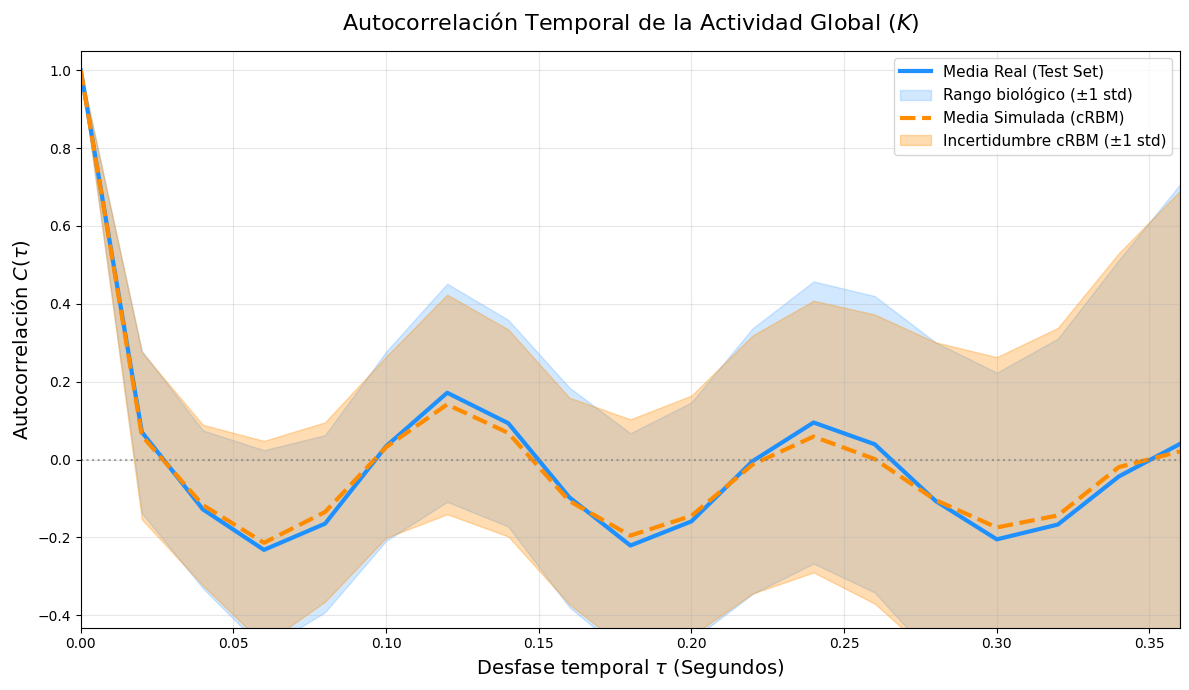

In [2]:
# ==========================================
# ANÁLISIS 3: AUTOCORRELACIÓN TEMPORAL cRBM
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import os

print("⏱️ Calculando Autocorrelación Temporal con varianza biológica (cRBM)...")

DT = 0.02  # 20 ms por frame
MAX_LAG = 19  # Ajustado a 70 para que coincida con tus 1.4 segundos (70 * 0.02)

def calc_autocorr(secuencia, max_lag):
    N = len(secuencia)
    if max_lag >= N: 
        max_lag = N - 1
        
    mu = np.mean(secuencia)
    var = np.var(secuencia)
    if var < 1e-10: 
        return np.zeros(max_lag)
    
    sec_norm = (secuencia - mu) / np.sqrt(var)
    
    autocorr = np.zeros(max_lag)
    for tau in range(max_lag):
        if tau == 0:
            autocorr[tau] = 1.0
        else:
            # Producto del vector consigo mismo desplazado tau posiciones
            autocorr[tau] = np.mean(sec_norm[:-tau] * sec_norm[tau:])
    return autocorr

# Recuperamos los parámetros que ya teníamos del modelo y los datos
# Asumiendo que ejecutaste la celda anterior, tenemos:
# - test_reales: array numpy de shape (Tiempo_Test, 120)
# - datos_gen: array numpy del h5 de shape (Num_Seqs, Tiempo_Gen, 120)
n_past = 10 # El valor de tu n_past (cámbialo si usaste otro)

# --- 1. DATOS SIMULADOS ---
# Excluimos la semilla inicial para medir puramente la "memoria" soñada por la red
sim_time_series = datos_gen
K_sim_ts = np.sum(sim_time_series, axis=2) # Sumamos la actividad de todas las neuronas (K)

autocorr_sim_all = np.array([calc_autocorr(seq, MAX_LAG) for seq in K_sim_ts])
autocorr_sim_mean = np.mean(autocorr_sim_all, axis=0)
autocorr_sim_std = np.std(autocorr_sim_all, axis=0)

# --- 2. DATOS REALES (Troceados para sacar estadística) ---
# Usamos test_reales que ya tiene formato (Tiempo, Neuronas) y ya es un numpy array
real_time_series = test_reales
K_real_ts = np.sum(real_time_series, axis=1)

# Queremos trocear la realidad en fragmentos del mismo tamaño que las secuencias simuladas
T_sim = sim_time_series.shape[1]
num_chunks = len(K_real_ts) // T_sim

# Si el test set es muy pequeño y no da para trozos grandes, forzamos para tener varianza
if num_chunks < 2:
    num_chunks = 10
    T_sim = len(K_real_ts) // num_chunks
    print(f"⚠️ Test set pequeño. Forzando a {num_chunks} trozos de longitud {T_sim}.")

print(f"   - Se han extraído {num_chunks} fragmentos reales independientes para calcular la varianza.")

# Recortamos el sobrante y hacemos el reshape para tener (num_chunks, tiempo)
K_real_chunks = K_real_ts[:num_chunks * T_sim].reshape(num_chunks, T_sim)

# Calculamos las métricas
autocorr_real_all = np.array([calc_autocorr(chunk, MAX_LAG) for chunk in K_real_chunks])
autocorr_real_mean = np.mean(autocorr_real_all, axis=0)
autocorr_real_std = np.std(autocorr_real_all, axis=0)

# --- 3. VISUALIZACIÓN ---
lags_sec = np.arange(MAX_LAG) * DT  

plt.figure(figsize=(12, 7))

# Plot Real con su desviación estándar (en azul)
plt.plot(lags_sec, autocorr_real_mean, lw=3, color='dodgerblue', label='Media Real (Test Set)')
plt.fill_between(lags_sec, 
                 autocorr_real_mean - autocorr_real_std, 
                 autocorr_real_mean + autocorr_real_std, 
                 color='dodgerblue', alpha=0.2, label='Rango biológico (±1 std)')

# Plot Simulado con su desviación estándar (en naranja)
plt.plot(lags_sec, autocorr_sim_mean, lw=3, color='darkorange', label='Media Simulada (cRBM)', linestyle='--')
plt.fill_between(lags_sec, 
                 autocorr_sim_mean - autocorr_sim_std, 
                 autocorr_sim_mean + autocorr_sim_std, 
                 color='darkorange', alpha=0.3, label='Incertidumbre cRBM (±1 std)')

plt.axhline(0, color='gray', linestyle=':', alpha=0.7)

plt.title('Autocorrelación Temporal de la Actividad Global ($K$)', fontsize=16, pad=15)
plt.xlabel('Desfase temporal $\\tau$ (Segundos)', fontsize=14)
plt.ylabel('Autocorrelación $C(\\tau)$', fontsize=14)
plt.xlim([0, lags_sec[-1]])

# Ajuste automático de límites Y
min_val = min(autocorr_sim_mean.min(), autocorr_real_mean.min())
plt.ylim([min_val - 0.2, 1.05])
plt.grid(True, alpha=0.3)

plt.legend(fontsize=11, loc='upper right')

# Guardado seguro
os.makedirs("stats/corr/corr_random", exist_ok=True)
plot_filename = "stats/corr/corr_random/corr_cRBM_1.png"
plt.savefig(plot_filename, dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()